Train Shape: (6818, 13)
Test Shape: (1705, 12)


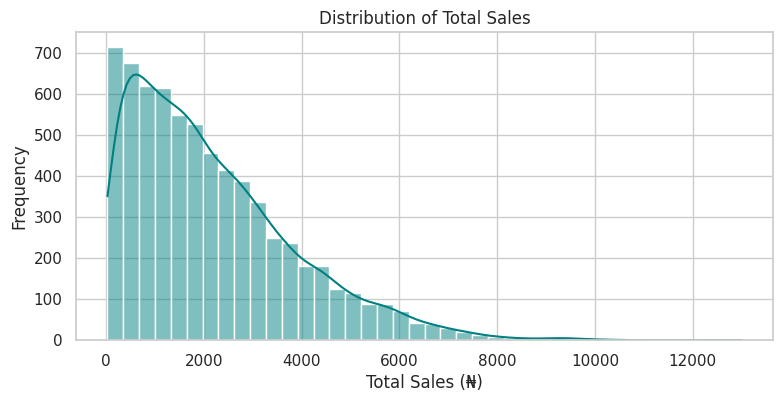

/tmp/ipykernel_3657/3345454519.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='store_format', y='total_sales', palette='Set2')


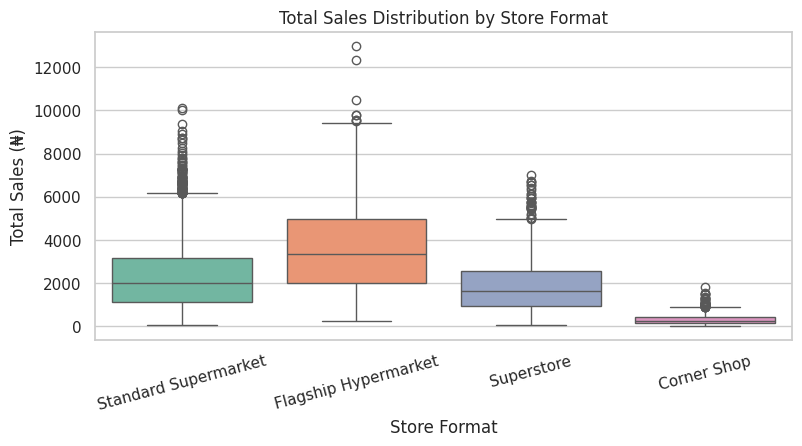

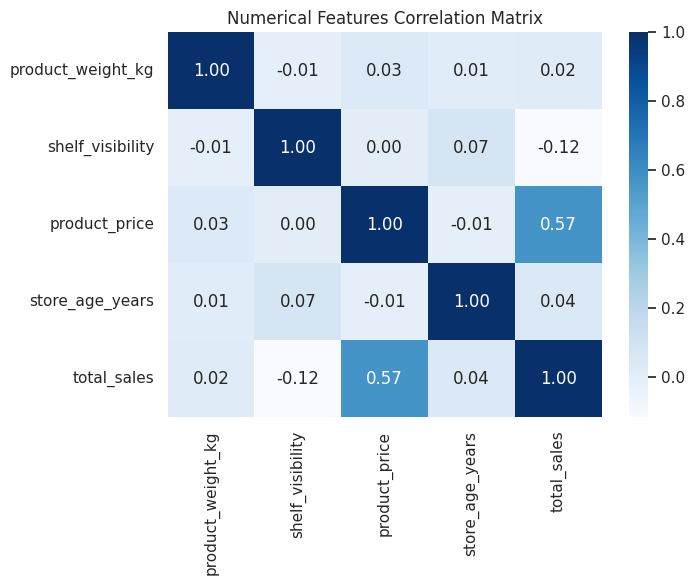

Overall Cross-Validation RMSE: 1116.0297
Saved submission.csv successfully.


In [2]:
# ==============================================================================
# DSN Bootcamp Qualification Hackathon 2026 - Machine Learning Track
# Complete Solution Notebook: EDA, Preprocessing, Modeling & Prediction
# ==============================================================================

# --- 1. Imports and Visualization Setup ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

# Set plot styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Load datasets
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f'Train Shape: {train.shape}')
print(f'Test Shape: {test.shape}')

# --- 2. Exploratory Data Analysis (EDA) ---

# Target Distribution Plot
plt.figure(figsize=(9, 4))
sns.histplot(train['total_sales'], kde=True, color='teal', bins=40)
plt.title('Distribution of Total Sales')
plt.xlabel('Total Sales (₦)')
plt.ylabel('Frequency')
plt.show()

# Total Sales by Store Format
plt.figure(figsize=(9, 4))
sns.boxplot(data=train, x='store_format', y='total_sales', palette='Set2')
plt.title('Total Sales Distribution by Store Format')
plt.xlabel('Store Format')
plt.ylabel('Total Sales (₦)')
plt.xticks(rotation=15)
plt.show()

# Numerical Correlation Heatmap
plt.figure(figsize=(7, 5))
num_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'total_sales']
sns.heatmap(train[num_cols].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Numerical Features Correlation Matrix')
plt.show()

# --- 3. Preprocessing & Feature Engineering ---

# Combine datasets for uniform processing
df = pd.concat([train.assign(is_train=1), test.assign(is_train=0, total_sales=np.nan)], ignore_index=True)

# Standardize Casing
df['product_category'] = df['product_category'].str.title().str.strip()
df['fat_content'] = df['fat_content'].str.title().str.strip()

# Missing Value Imputation
weight_map = df.groupby('product_code')['product_weight_kg'].mean()
df['product_weight_kg'] = df['product_weight_kg'].fillna(df['product_code'].map(weight_map))
df['product_weight_kg'] = df['product_weight_kg'].fillna(df['product_weight_kg'].median())

visibility_map = df[df['shelf_visibility'] > 0].groupby('product_code')['shelf_visibility'].mean()
df['shelf_visibility'] = np.where(
    df['shelf_visibility'] == 0,
    df['product_code'].map(visibility_map),
    df['shelf_visibility']
)
df['shelf_visibility'] = df['shelf_visibility'].fillna(df['shelf_visibility'].median())

store_size_mode = df.groupby('store_format')['store_size'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else 'Medium'
)
df['store_size'] = df['store_size'].fillna(df['store_format'].map(store_size_mode))

# Feature Engineering
df['price_per_weight'] = df['product_price'] / (df['product_weight_kg'] + 1e-5)
df['store_establishment_year'] = 2026 - df['store_age_years']

# Categorical One-Hot Encoding
cat_cols = ['fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Separate Train and Test Datasets
train_clean = df[df['is_train'] == 1].drop(columns=['is_train'])
test_clean = df[df['is_train'] == 0].drop(columns=['is_train', 'total_sales'])

X = train_clean.drop(columns=['id', 'product_code', 'total_sales'])
y = train_clean['total_sales']
X_test = test_clean.drop(columns=['id', 'product_code'])

# --- 4. Cross-Validation & Modeling ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]

    model = HistGradientBoostingRegressor(random_state=42, max_iter=200, learning_rate=0.05)
    model.fit(X_train_fold, y_train_fold)

    oof_preds[val_idx] = model.predict(X_val_fold)
    test_preds += model.predict(X_test) / kf.n_splits

cv_rmse = np.sqrt(mean_squared_error(y, oof_preds))
print(f'Overall Cross-Validation RMSE: {cv_rmse:.4f}')

# --- 5. Export Final Predictions ---
submission = pd.DataFrame({
    'id': test_clean['id'],
    'total_sales': np.clip(test_preds, 0, None)
})
submission.to_csv('submission.csv', index=False)
print('Saved submission.csv successfully.')